This notebook is a minimal proof of concept for the KSW estimator. This uses premade elsner sims to ensure accuracy and can be used as a test to ensure the estimator is working correctly.

First lets setup some imports, you will need numpy, matplotlib, healpy, pixell, camb, tqdm, and of course ksw installed.

In [1]:
import os
import requests
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from tqdm import trange

import healpy as hp
import pixell
import camb

from ksw import KSW, Cosmology, Shape, Data

Some global paramters to configure everything.

In [2]:
ndata = 100 # determine the number of elsner sims used
nsteps = 100 # the number of ksw steps to use

lmax = 1024 # set by elsner
# l_buff = 128 # buffer for ell range
nell = lmax + 1

# setup some polarization stuff
npols = 1
pols = ("T") if npols == 1 else ("T", "E")
nspec = 1 if npols == 1 else 3

# this is where the data will be saved
data_dir = "data/elsner"
ksw_file = f"{data_dir}/ksw_elsner.hdf5"
os.makedirs(data_dir, exist_ok=True)

# some scale factors
tscale = 2.7255e6

# get our fnl values, and shape them accordingly
# fnls = np.array([5] * ndata) 
fnls = np.random.uniform(-100, 100, ndata)
if npols == 1:
    fnls = fnls[:, None]
else:
    fnls = fnls[:, None, None]

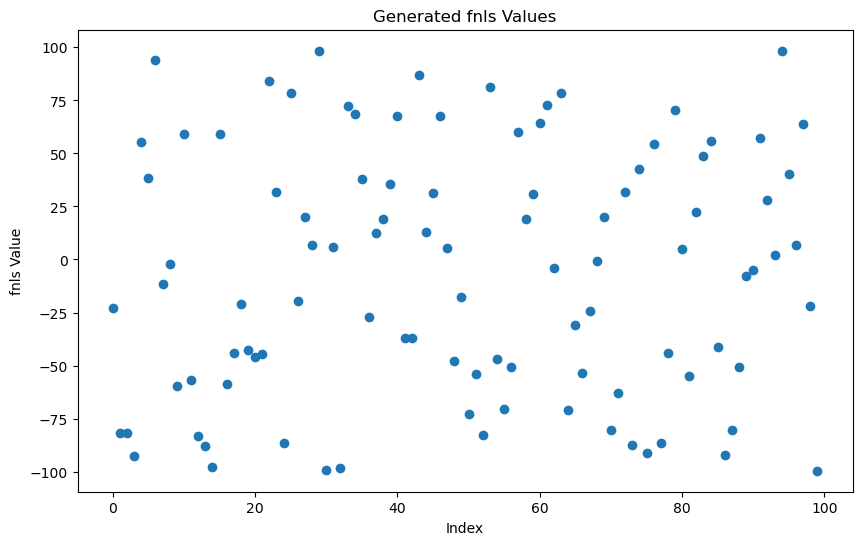

In [3]:
# lets make a simple plot of the fnls to check the distribution
plt.figure(figsize=(10, 6))
plt.scatter(range(len(fnls)), fnls)
plt.title('Generated fnls Values')
plt.xlabel('Index')
plt.ylabel('fnls Value')
plt.show()

Here we download the data files. These are the elsner sims which are exact sims based on the WMAP5+BAO+SN cosmological data provided by LAMBDA

In [4]:
# First load in the CLs used to generate the elsner sims
# The spherical harmonic coefficients are provided in dimensionless units, i. e. dT/T.
URL0 = "http://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/cl_wmap5_bao_sn.txt"
file0 = f"{data_dir}/cl_wmap5_bao_sn.dat"
if not os.path.exists(file0):
    with requests.Session() as s, open(file0, "wb") as f:
        f.write(s.get(URL0).content)

# Use numpy to read in the data
cls = np.loadtxt(file0).transpose()
ells = cls[0].astype(int)

cls[3] = 0

# new signal
s_ell = np.zeros((2, 2, nell))
s_ell[0, 0, 2:] = cls[1, :lmax-1] # T
s_ell[1, 1, 2:] = cls[2, :lmax-1] # E
# s_ell[2, 2, 2:] = cls[3] # B, dont have
s_ell[0, 1, 2:] = cls[3, :lmax-1] # TE
s_ell[1, 0, 2:] = cls[3, :lmax-1] # TE
s_ell *= tscale**2
print(s_ell.dtype, s_ell)

float64 [[[0.00000000e+00 0.00000000e+00 1.21578246e+03 ... 5.99675495e-03
   5.98963184e-03 5.98318999e-03]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]]

 [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 5.50775359e-02 ... 2.42349783e-04
   2.40777326e-04 2.39180813e-04]]]


In [5]:
# here we will load the alms
alm_l = []
alm_nl = []
hdu = (1,) if npols == 1 else (1, 2)

# we start at 1 because that's how the sims work
for num in trange(1, ndata + 1, desc="Checking for and downloading files", unit=" file"):
    URL1 = (
        "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_l_"
        + str(num).zfill(4)
        + "_v3.fits"
    )
    URL2 = (
        "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_nl_"
        + str(num).zfill(4)
        + "_v3.fits"
    )

    file1 = f"{data_dir}/alm_l_" + str(num).zfill(4) + "_v3.fits"
    if not os.path.exists(file1):
        with requests.Session() as s, open(file1, "wb") as f:
            f.write(s.get(URL1).content)

    file2 = f"{data_dir}/alm_nl_" + str(num).zfill(4) + "_v3.fits"
    if not os.path.exists(file2):
        with requests.Session() as s, open(file2, "wb") as f:
            f.write(s.get(URL2).content)

    # Load data into alm_l and alm_nl
    alm_l.append(hp.read_alm(file1, hdu))
    alm_nl.append(hp.read_alm(file2, hdu))

# convert to numpy arrays
alm_l = np.array(alm_l)
alm_nl = np.array(alm_nl)

# finally get our data
alms = (alm_l + fnls * alm_nl) * tscale

Checking for and downloading files: 100%|██████████| 100/100 [01:00<00:00,  1.65 file/s]


Lets make a quick plot of the power spectrum to see what it looks like.

In [6]:
# # here we make a quick plot of the loaded alms, pick one at random

# # Pick a random simulation index
# sim_index = np.random.randint(0, ndata - 1)

# ells = np.arange(2, nell)
# scale = (ells * (ells + 1) / 2 / np.pi)

# plt.figure(figsize=(12, 8))
# plot_func = plt.semilogy
# if npols == 1:
#     plot_func(ells, scale * cls[1], label='cls')
#     plot_func(ells, scale * pixell.curvedsky.alm2cl(alm_l[sim_index])[2:], label='alm_l')
#     plot_func(ells, scale * pixell.curvedsky.alm2cl(alm_nl[sim_index])[2:], label='alm_nl')
#     plot_func(ells, scale * pixell.curvedsky.alm2cl(alms[sim_index])[2:], label='alms, tscaled')
# else:
#     for p in range(npols):
#         plot_func(ells, scale * cls[p+1], label='cls')
#         plot_func(ells, scale * pixell.curvedsky.alm2cl(alm_l[sim_index, p])[2:], label='alm_l')
#         plot_func(ells, scale * pixell.curvedsky.alm2cl(alm_nl[sim_index, p])[2:], label='alm_nl')
#         plot_func(ells, scale * pixell.curvedsky.alm2cl(alms[sim_index, p])[2:], label='alms, tscaled')

# plt.title(f'Simulation {sim_index + 1}: alm_l, alm_nl, and alms')
# plt.xlabel('ells')
# plt.ylabel('Value')
# plt.legend()
# plt.grid(True)
# plt.show()

radii just gets our radii used for the KSW estimator, we grab values based on smith and zaldarriaga sampling

In [7]:
def radii():
        """
        This method sets up the radii
        See Smith and Zaldarriaga (2011) Section 5.2 for more details.
        """
        #    start,  stop, resolution
        ranges = [
            (0, 9500, 150),
            (9500, 11000, 300),
            (11000, 13800, 150),
            (13800, 14600, 400),
            (14600, 16000, 100),
            (16000, 50000, 100),
        ]
        radii = []

        r_min = int(1)
        r_max = int(50000)

        for r in ranges:
            start = max(r_min, r[0])
            end = min(r_max, r[1])

            if start >= end:
                continue

            if r == ranges[-1]:  # For the last range, use logspace
                temp_radii = np.logspace(np.log10(start), np.log10(end), num=r[2])
            else:
                temp_radii = np.linspace(start, end, num=r[2], endpoint=False)

            radii.extend(temp_radii)

        return np.array([r for r in radii if r_min <= r <= r_max])

Here is where we actually start using the KSW estimator

In [8]:
# these are set by the elsner sims, see the paper for more details
cosmo_params = {
        "H0": 70.1,
        "As": 2.457e-9,
        "pivot_scalar": 0.002,
        "ns": 0.96,
        "ombh2": 0.02256,
        "omch2": 0.1143,
        "tau": 0.084
    }
camb_params = camb.set_params(**cosmo_params)

# new
ip = camb.initialpower.InitialPowerLaw()
ip.set_params(As=cosmo_params["As"], ns=cosmo_params["ns"])
camb_params.set_initial_power(ip)

# init our cosmology
cosmo = Cosmology(camb_params, verbose=True)
cosmo.compute_transfer(lmax) # + l_buff)
cosmo.compute_c_ell()

Updated CAMB param: DoLateRadTruncation from True to False.
Updated CAMB param: AccuracyBoost from 1.0 to 2.
Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: lSampleBoost from 1.0 to 2.
Updated CAMB param: lAccuracyBoost from 1.0 to 2.
Updated CAMB param: AccurateBB from False to True.


In [9]:
# noise and beam are disabled, for noise this means very small values for beam this means it should be 1
# beam = np.ones((npols, nell))
# noise = np.ones((nspec, nell)) * 1e-16
# if nspec == 3:
#     # needed if we are using T, and E to prevent singular matrix
#     noise[2] = 1e-20

# here we generate our local shape
loc_shape = Shape.prim_local(cosmo_params["ns"], cosmo_params["pivot_scalar"])
cosmo.add_prim_reduced_bispectrum(loc_shape, radii())

In [10]:

def icov_func():
    """
    Returned the inverse covariance of the data, used in the KSW estimator.

    Function takes (npol, nelem) alm-like complex array "alm" and returns the
    inverse-variance-weighted version of that array. Specifically:
    (B^{-1} N B^{-1} + S)^{-1} B^{-1} a, where a = B s + n, B is the beam
    and N^{-1} and S^{-1} are the inverse noise and signal covariance
    matrices, respectively.

    Parameters:
    - alm (ndarray): (npol, nelem) alm-like complex array.
    """

    # B_inv = 1 / beam

    # want S = c_ells but need to add the mono and dipole terms (0) since elsner does not have these
    # S = np.zeros((npols, nell))
    # S[:, 2:] = c_ells[:npols]
    
    
    # factor = (B_inv * noise * B_inv + S) ** (-1) * B_inv
    # factor[:, :2] = 0 # set mono and dipole to 0

    # lmax = s_ell.shape[2]
    factor = np.zeros_like(s_ell)
    factor[..., 2:] = np.linalg.inv(s_ell[..., 2:].T).T

    def _func(alm):
        ret = np.zeros_like(alm)
        for pol in range(npols):
            # we drop TE
            ret[pol] = hp.almxfl(alm[pol], factor[pol, pol])
        return ret

    return _func

ksw = KSW(
    cosmo.red_bispectra,
    None, #icov_func(),
    lmax,
    pols,
    "single",
)


We need to initialize the estimator, check for a saved state and use that or start from scratch

In [11]:
# if os.path.exists(ksw_file):
#     os.remove(ksw_file)

# if os.path.exists(ksw_file):
#     ksw.start_from_read_state(ksw_file)
# else:
#     # generates our data used for the stepping, this can just be gaussian so it is simple
#     data = Data(lmax, noise, beam, pols, cosmo)
#     step_sims = [data.compute_alm_sim() for _ in range(nsteps)]

#     pbar = tqdm(total=nsteps, desc="Running steps", unit=" step")
#     def runner(i):
#         pbar.update(1)
#         return step_sims[i]

#     ksw.step_batch(runner, range(nsteps))
#     ksw.write_state(ksw_file)

# fisher = float(ksw.compute_fisher())
# print(f"Fisher: {fisher}")
# print(f"standard deviation: {np.sqrt(1 / fisher)}")

In [12]:
factor = np.zeros_like(s_ell)
factor[..., 2:] = np.linalg.inv(s_ell[..., 2:].T).T
fisher, mat = ksw.compute_fisher_isotropic(factor[:npols, :npols], return_matrix=True)
print("fisher isotropic", fisher, np.sqrt(1 / fisher))
print(mat)

fisher isotropic 0.015247377 8.09845989603714
[[ 0.0000000e+00  1.9666160e-33  2.4569644e-32 ...  2.3165069e-32
  -2.9024387e-32 -1.2048704e-32]
 [ 1.9666160e-33  2.7000371e-20  4.2541142e-19 ...  9.5838014e-19
  -7.7436182e-19 -4.6419267e-19]
 [ 2.4569644e-32  4.2541142e-19  7.0742769e-18 ...  1.6336733e-17
  -1.3482184e-17 -7.8761135e-18]
 ...
 [ 2.3165069e-32  9.5838014e-19  1.6336733e-17 ...  7.8821498e-17
  -3.2634485e-17 -3.7757341e-17]
 [-2.9024387e-32 -7.7436182e-19 -1.3482184e-17 ... -3.2634485e-17
   3.5887092e-17  1.0486268e-17]
 [-1.2048704e-32 -4.6419267e-19 -7.8761135e-18 ... -3.7757341e-17
   1.0486268e-17  1.5294027e-17]]


Print fisher as we can check that value against the expected value

And here we use the estimator to predict the given fnl

In [18]:
func = icov_func()
icov_alms = np.array([func(alm[None, :]) for alm in alms])

pbar = tqdm(total=ndata, desc="Running estimates", unit=" sim")
def runner(i):
    pbar.update(1)
    print("True fnl", fnls[i])
    return icov_alms[i]

# if using fisher_iso set lin_term=0
estimates, cubic, linear, fishers = ksw.compute_estimate_batch(
    runner, range(ndata), fisher=fisher, lin_term=0
)

(100, 525825)


Running estimates:   0%|          | 0/100 [00:00<?, ? sim/s]

True fnl [-22.83269434]
fnl=-21.40731223780286, t_cubic=-0.32640535244718194, lin_term=0, fisher=0.015247377
True fnl [-81.72365837]
fnl=-79.71634137250847, t_cubic=-1.2154650809243321, lin_term=0, fisher=0.015247377
True fnl [-81.81076157]
fnl=-91.23306090871432, t_cubic=-1.391064841300249, lin_term=0, fisher=0.015247377
True fnl [-92.69635273]
fnl=-89.61898457562192, t_cubic=-1.3664544115308672, lin_term=0, fisher=0.015247377
True fnl [55.2082338]
fnl=52.76743934336631, t_cubic=0.8045650217682123, lin_term=0, fisher=0.015247377
True fnl [38.23110808]
fnl=43.915551386516746, t_cubic=0.6695969521533698, lin_term=0, fisher=0.015247377
True fnl [94.26650356]
fnl=83.17465875356238, t_cubic=1.2681953485589474, lin_term=0, fisher=0.015247377
True fnl [-11.74434464]
fnl=-2.9194980639206105, t_cubic=-0.04451468656770885, lin_term=0, fisher=0.015247377
True fnl [-2.2179419]
fnl=0.8099578688797151, t_cubic=0.01234973268583417, lin_term=0, fisher=0.015247377
True fnl [-59.81153017]
fnl=-65.63559

Lets make some plots so we can inspect the results

(100,)
(100, 1)


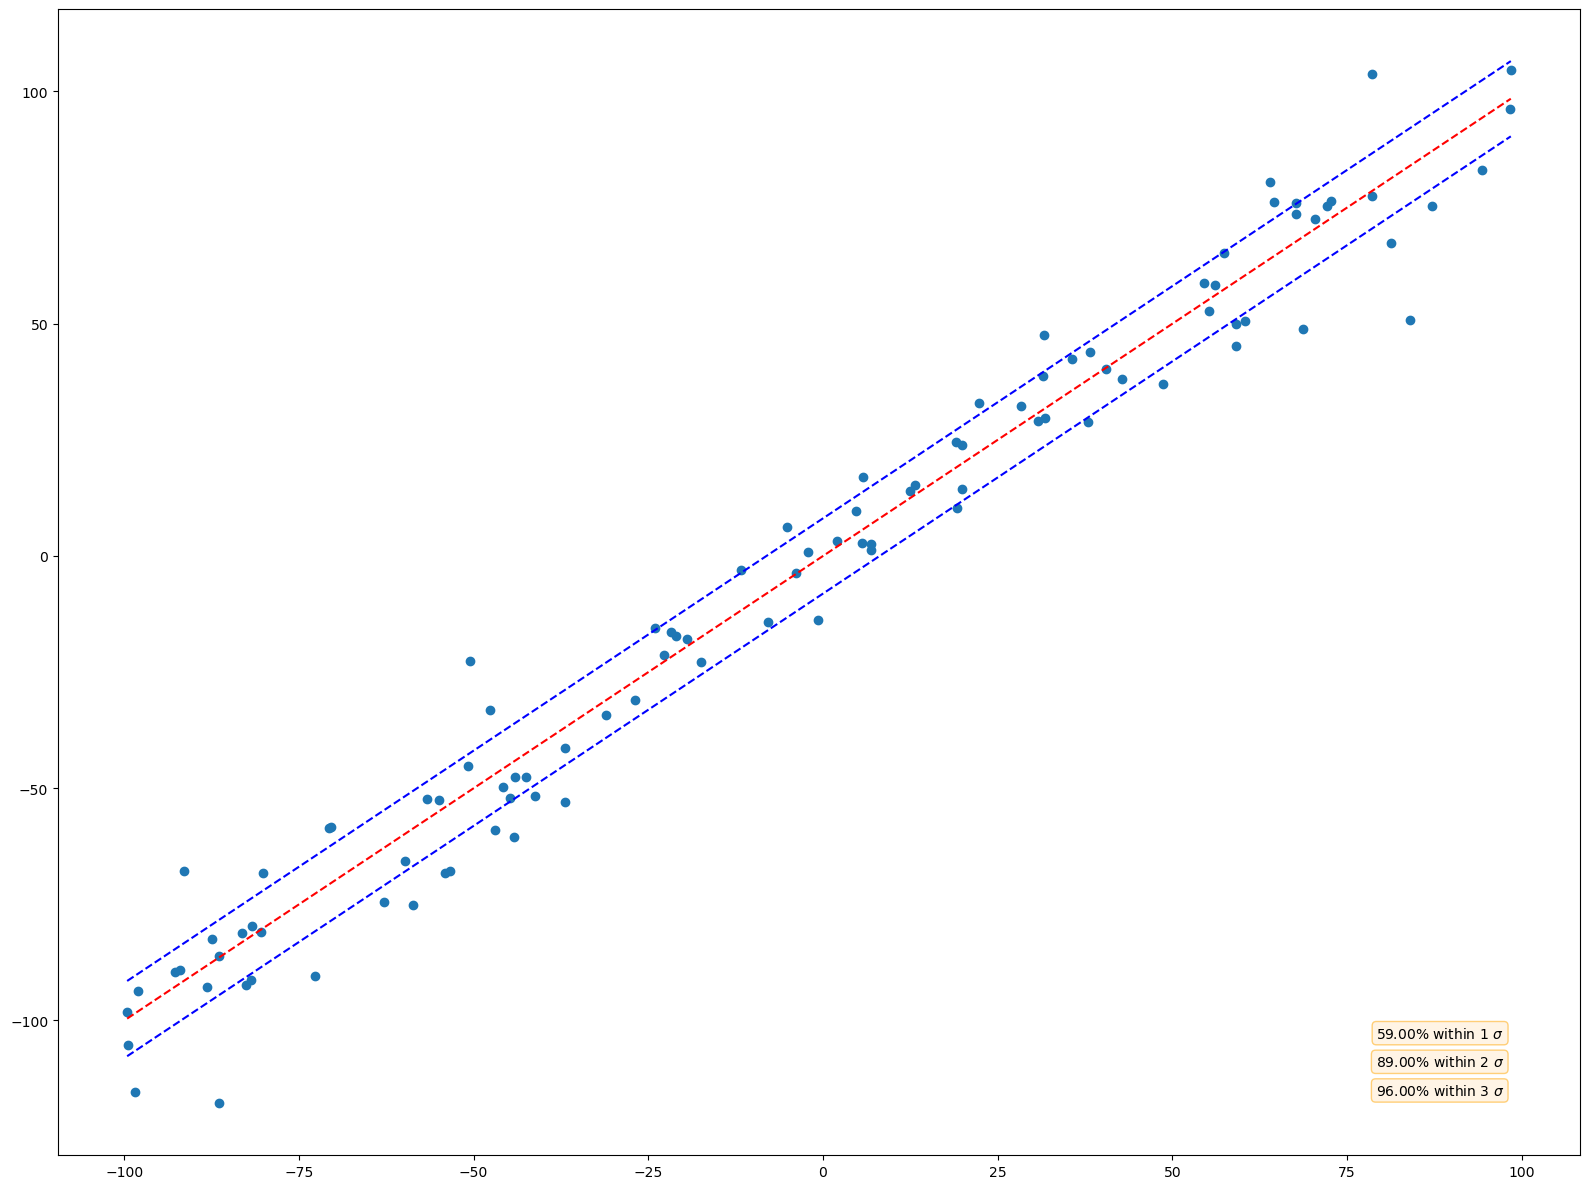

In [21]:
std_dev = np.sqrt(1 / fisher)

plt.figure(figsize=(16, 12))
plt.scatter(fnls[:ndata], estimates, label="Estimates")

# Truth line
line = [min(fnls), max(fnls)]
plt.plot(line, line, color="red", linestyle="--", label="Truth")
plt.plot(line, line + std_dev, color="blue", linestyle="--", label="Fisher")
plt.plot(line, line - std_dev, color="blue", linestyle="--")

# lets also print the number of points within 1 sigma
diff = np.array(estimates).flatten() - np.array(fnls[:ndata]).flatten()
diff = np.abs(diff)
bbox = dict(boxstyle="round", fc="blanchedalmond", ec="orange", alpha=0.5)
for i in range(1, 4):
    within = np.sum(diff < i * std_dev) / len(diff) * 100
    plt.text(
        0.95,
        0.1 - (i - 1) * 0.025,
        f"{within:.2f}% within {i} $\\sigma$",
        bbox=bbox,
        ha="right",
        va="bottom",
        transform=plt.gca().transAxes,
    )

plt.tight_layout()
plt.show()